In [1]:
# WARNING #####################################################################
# this notebook should be run in Colab unless you have an already fully
# functional conda environment with both `tensorflow` and `shap`.
# Remember to upload "emotion_model_weights.keras" file and the folder `shap`
# in your google drive.
###############################################################################
import tensorflow as tf
import shap
import numpy as np
import pandas as pd
import os
from tqdm.notebook import tqdm

In [2]:
# Mounting google drive into the current working session
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# --- Configuration ---
DIR = "/content/drive/MyDrive/shap"  # Folder name containing images
MODEL_PATH = '/content/drive/MyDrive/emotion_model_weights.keras' # the trained model
# images settings
IMG_SIZE = 48
BATCH_SIZE = 1 # we do not need batch here

In [4]:
# --- Load the Trained Model ---
if not os.path.exists(MODEL_PATH):
    print(f"Error: Model file '{MODEL_PATH}' not found.")
    exit()

print("Loading model...")
model = tf.keras.models.load_model(MODEL_PATH)
print("OK")

Loading model...
OK


In [5]:
# --- Load Data ---
print("Loading data...")
img_ds = tf.keras.utils.image_dataset_from_directory(
    DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='categorical',
    shuffle=False
)

Loading data...
Found 7 files belonging to 7 classes.


In [6]:
# Check uploaded images for each category
print("num\temotion")
print("===================")
for emo in sorted(os.listdir(DIR)):
    n_train = len(os.listdir(os.path.join(DIR, emo)))
    print(n_train, "\t", emo)

num	emotion
1 	 angry
1 	 disgust
1 	 fear
1 	 happy
1 	 neutral
1 	 sad
1 	 surprise


In [7]:
selected_images_per_class = {}

# Iterate through the uploaded dataset
for images_batch, labels_batch in tqdm(img_ds):
    # The batch is 1 but, for scalability, we iterate over it anyhoo
    for i in range(images_batch.shape[0]):
        image = images_batch[i]
        label = labels_batch[i]

        # Convert one-hot encoded label to class index
        class_index = tf.argmax(label).numpy()

        # Get class name
        class_name = img_ds.class_names[class_index]

        # If an image for this class hasn't been stored yet, store it
        if class_name not in selected_images_per_class:
            selected_images_per_class[class_name] = image
            print(f"Added image for class: {class_name}")

        # Check if all 7 classes have been covered
        if len(selected_images_per_class) == len(img_ds.class_names):
            break # Break inner loop
    # Check again in the outer loop
    if len(selected_images_per_class) == len(img_ds.class_names):
        break # Break outer loop

print(f"Selected classes: {list(selected_images_per_class.keys())}")
print(f"Total images selected: {len(selected_images_per_class)}")

  0%|          | 0/7 [00:00<?, ?it/s]

Added image for class: angry
Added image for class: disgust
Added image for class: fear
Added image for class: happy
Added image for class: neutral
Added image for class: sad
Added image for class: surprise
Selected classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total images selected: 7


In [8]:
# define a masker that is used to mask out partitions of the input image.
# The masker should be initialized with the shape of a single image.
masker = shap.maskers.Image("blur(48,48)", (IMG_SIZE, IMG_SIZE, 1))

In [9]:
# python function to get model output (needed for the SHAP explainer)
def f(x):
    tmp = x.copy()
    return model(tmp)

In [10]:
# create an explainer with model function, image masker and class names
explainer = shap.Explainer(f, masker, output_names=img_ds.class_names)

In [11]:
# enable EagerTensor (needed for numpy to correctly handle keras tensors)
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()

In [12]:
# Convert TensorFlow tensors in 'images' list to NumPy arrays with uint8 dtype.
# This is necessary because shap.maskers.Image uses OpenCV's inpaint function,
# which expects NumPy arrays (typically with uint8 or float32 data types).
# The current images list contains TensorFlow tensors with float32.
selected_images_np = {}
for class_name, image_tensor in selected_images_per_class.items():
    # Convert TensorFlow tensor to NumPy array and then to uint8
    # The image_tensor has shape (48, 48, 1), so we keep it as is.
    selected_images_np[class_name] = image_tensor.numpy().astype(np.uint8)

print(f"Converted {len(selected_images_np)} selected images to NumPy arrays (uint8).")

Converted 7 selected images to NumPy arrays (uint8).


In [13]:
# Check the images shape, should be (IMG_SIZE, IMG_SIZE, 1)
selected_images_np['angry'].shape

(48, 48, 1)

In [14]:
# Check the images tensor shape for SHAP, should be (7, IMG_SIZE, IMG_SIZE, 1)
np.array(list(selected_images_np.values())).shape

(7, 48, 48, 1)

In [15]:
# Explain images using max_evals evaluations of the underlying trained model.
# WARNING: this could take time, approximately 13 min in a free Colab env, so...
#          think about using a cup of coffee in the meanwhile :)
shap_values = explainer(np.array(list(selected_images_np.values())),
                        max_evals=5000, # the more evals, the more detailed plot
                        batch_size=4, # SHAP's internal batching for model calls
                        outputs=shap.Explanation.argsort.flip
                        )

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer:  14%|█▍        | 1/7 [00:00<?, ?it/s]

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer:  43%|████▎     | 3/7 [04:57<04:47, 71.97s/it]

  0%|          | 0/4998 [00:00<?, ?it/s]

...

PartitionExplainer explainer:  86%|████████▌ | 6/7 [11:55<02:03, 123.02s/it]

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 7/7 [14:15<00:00, 128.63s/it]

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer: 8it [16:40, 142.95s/it]


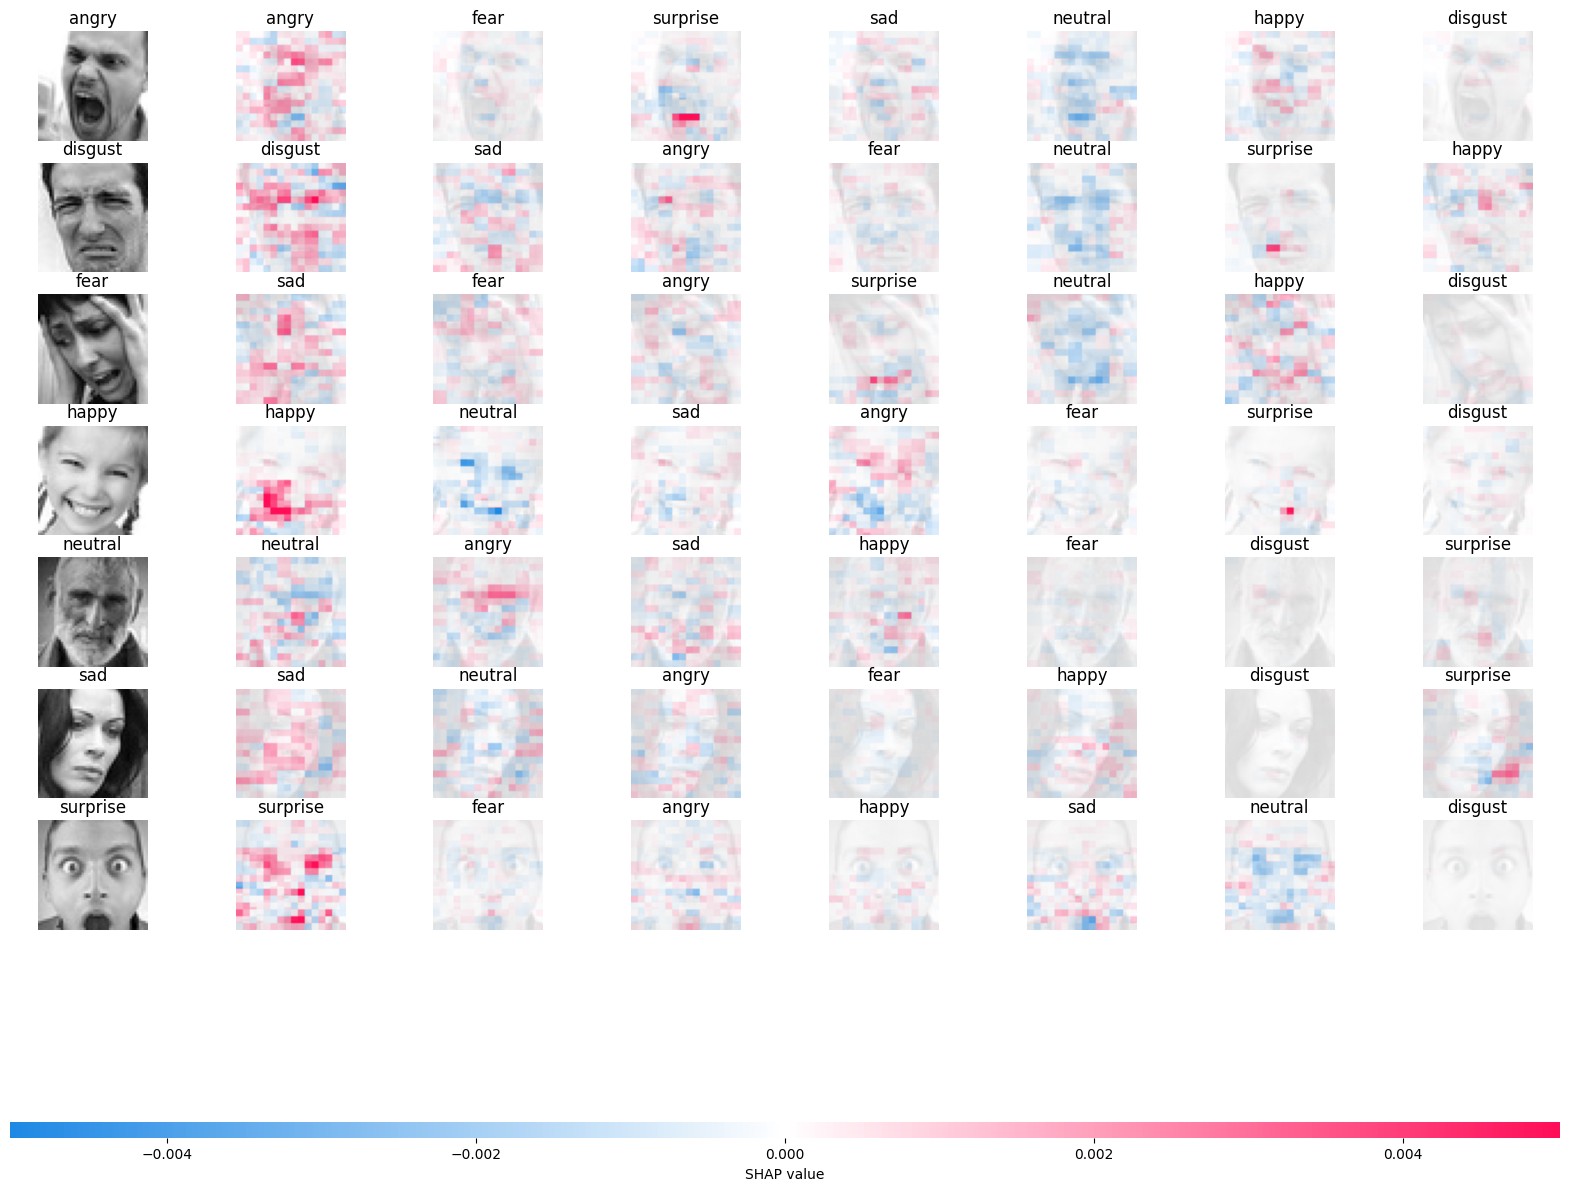

In [16]:
# output with shap values
shap.image_plot(shap_values, true_labels=list(selected_images_np.keys()))